In [2]:
# Import clean_files from wrangle.py
from wrangle import clean_files

# Load data
df = clean_files("./data/buenos-aires-real-estate-*.csv")  # <--- "./data/buenos-aires-real-estate-*.csv"

# Define target and features
target_col = "price_aprox_usd"
feature_cols = [col for col in df.columns if col not in target_col]

X = df[feature_cols]  # <--- df[feature_cols]
y = df[target_col]  # <--- df[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

Features shape: (6247, 4)
Target shape: (6247,)
Feature columns: ['surface_covered_in_m2', 'lat', 'lon', 'neighborhood']


In [3]:
# imports first
from sklearn.model_selection import train_test_split
import pandas as pd

# Perform train-test split
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X, y, test_size=0.2, random_state=42  # <--- X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_3.shape[0]} samples")
print(f"Test set: {X_test_3.shape[0]} samples")

Training set: 4997 samples
Test set: 1250 samples


In [4]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1169844027", h="3298dbabb7", width=700, height=450) 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from category_encoders import OneHotEncoder

In [7]:
model_ridge_3 = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # <--- True
    StandardScaler(),  # <--- StandardScaler()
    Ridge(alpha=1.0)  # <--- Ridge(alpha=1.0)
)

# Display the pipeline
model_ridge_3

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,None
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [8]:
# Fit model
model_ridge_3.fit(X_train_3, y_train_3)  # <--- model_ridge_3.fit(X_train_3, y_train_3)

# Predict on training data
y_pred_ridge_train = model_ridge_3.predict(X_train_3)  # <--- model_ridge_3.predict(X_train_3)
rmse_ridge_train = root_mean_squared_error(y_train_3, y_pred_ridge_train)

# Predict on test data
y_pred_ridge_test = model_ridge_3.predict(X_test_3)  # <--- model_ridge_3.predict(X_test_3)
rmse_ridge_test = root_mean_squared_error(y_test_3, y_pred_ridge_test)

print(f"Ridge Training RMSE: ${rmse_ridge_train:,.2f}")
print(f"Ridge Test RMSE: ${rmse_ridge_test:,.2f}")

Ridge Training RMSE: $34,200.44
Ridge Test RMSE: $33,087.85


In [10]:
model_lasso_3 = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # <--- OneHotEncoder(use_cat_names=True)
    StandardScaler(),  # <--- StandardScaler()
    Lasso(alpha=100, max_iter=10000)
)

model_lasso_3.fit(X_train_3, y_train_3)

# Calculate test RMSE
y_pred_lasso_test = model_lasso_3.predict(X_test_3)
rmse_lasso_test = root_mean_squared_error(y_test_3, y_pred_lasso_test)

print(f"Lasso Test RMSE: ${rmse_lasso_test:,.2f}")

Lasso Test RMSE: $33,053.24


In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from category_encoders import OneHotEncoder 
import numpy as np
import pandas as pd

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
print("Checking Shapes")
print("X_train_3:", X_train_3.shape, "y_train_3:", y_train_3.shape)
print("X_test_3:", X_test_3.shape, "y_test_3:", y_test_3.shape)

# Test a wide range of alphas across 9 orders of magnitude
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for a in alphas:
    # Create and fit pipeline
    model = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        StandardScaler(),
        Ridge(alpha=a)  # <--- Ridge(alpha=a)
    )
    model.fit(X_train_3, y_train_3) # <-- fit on train

    # Calculate RMSE for training and test
    rmse_train = root_mean_squared_error(y_train_3, model.predict(X_train_3))  # <-- y_train_3 & X_train_3
    rmse_test = root_mean_squared_error(y_test_3, model.predict(X_test_3))   # <-- y_test_3 & X_test_3

    ridge_results.append({
        "alpha": a,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test
    })

df_ridge_results = pd.DataFrame(ridge_results)
print(df_ridge_results)

Checking Shapes
X_train_3: (4997, 4) y_train_3: (4997,)
X_test_3: (1250, 4) y_test_3: (1250,)
      alpha    rmse_train     rmse_test
0     0.001  34200.432952  33088.372087
1     0.010  34200.432953  33088.367313
2     0.100  34200.432974  33088.319603
3     1.000  34200.435086  33087.845694
4    10.000  34200.639955  33083.415038
5   100.000  34216.977947  33062.388861
6  1000.000  35069.439956  33744.376028


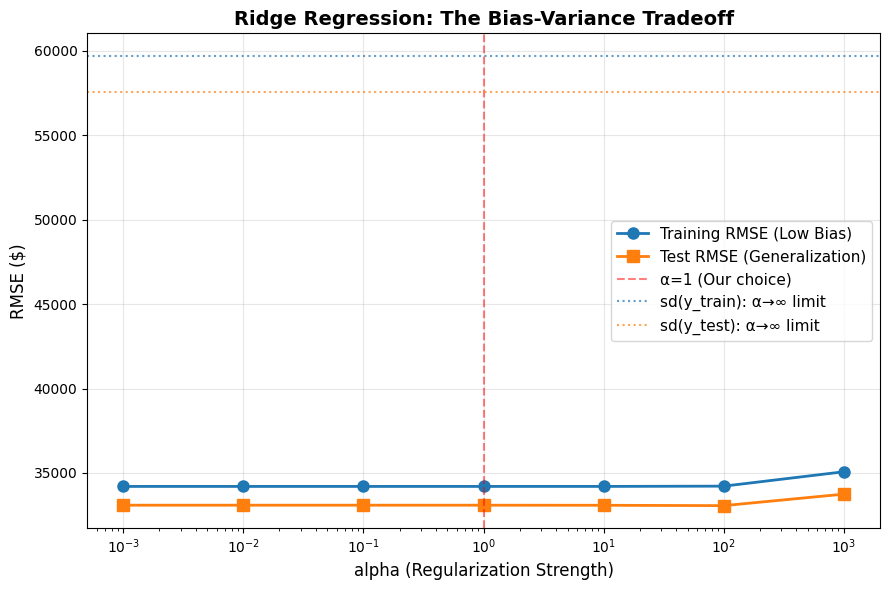

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_ridge_results["alpha"], df_ridge_results["rmse_train"],
        marker='o', linewidth=2, markersize=8, label="Training RMSE (Low Bias)")
ax.plot(df_ridge_results["alpha"], df_ridge_results["rmse_test"],
        marker='s', linewidth=2, markersize=8, label="Test RMSE (Generalization)")
ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label="α=1 (Our choice)")

# Where each curve must converge as alpha -> infinity (model predicts the training mean)
ax.axhline(y_train_3.std(), color='C0', linestyle=':', alpha=0.7, label="sd(y_train): α→∞ limit")
ax.axhline(y_test_3.std(), color='C1', linestyle=':', alpha=0.7, label="sd(y_test): α→∞ limit")
ax.set_xlabel("alpha (Regularization Strength)", fontsize=12)
ax.set_ylabel("RMSE ($)", fontsize=12)
ax.set_xscale("log")
ax.set_title("Ridge Regression: The Bias-Variance Tradeoff", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
lasso_results = []
alphas_lasso = [0.1, 1, 10, 100, 1000]

for a in alphas_lasso:
    model = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        StandardScaler(),
        Lasso(alpha=a, max_iter=10000)
    )
    model.fit(X_train_3, y_train_3)  # <-- fit on train

    rmse_train = root_mean_squared_error(y_train_3, model.predict(X_train_3))  # <-- y_train_3, X_train_3
    rmse_test = root_mean_squared_error(y_test_3, model.predict(X_test_3))  # <-- y_test_3, X_test_3
    non_zero_features = (model.named_steps["lasso"].coef_ != 0).sum()

    lasso_results.append({
        "alpha": a,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "non_zero_features": non_zero_features
    })

df_lasso_results = pd.DataFrame(lasso_results)
print(df_lasso_results)

/usr/local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.670e+11, tolerance: 1.781e+09
  model = cd_fast.enet_coordinate_descent(


    alpha    rmse_train     rmse_test  non_zero_features
0     0.1  34200.432980  33088.297202                 59
1     1.0  34200.435537  33087.686878                 58
2    10.0  34200.691205  33081.797922                 58
3   100.0  34224.825010  33053.242280                 56
4  1000.0  34772.392675  33646.034886                 27


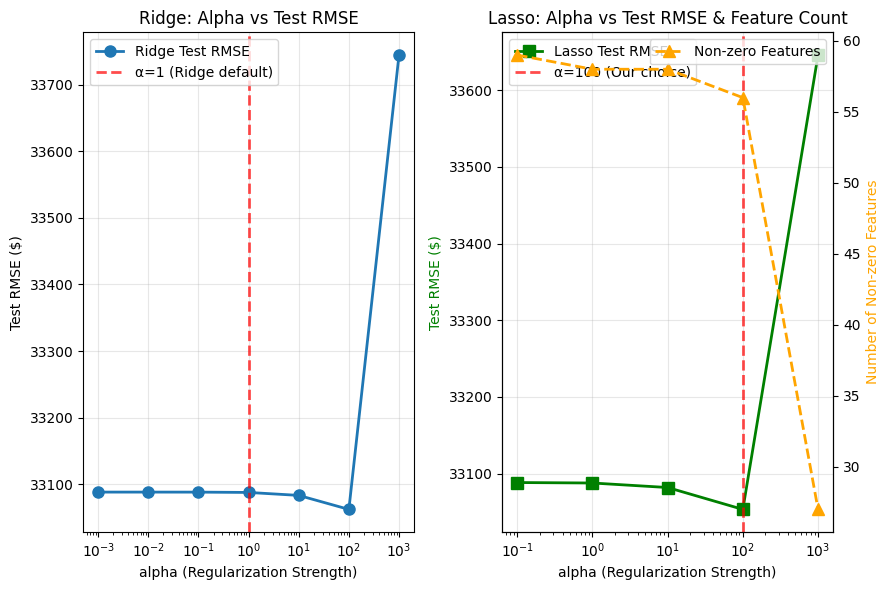

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# Ridge comparison
ax1.plot(df_ridge_results["alpha"], df_ridge_results["rmse_test"],
         marker='o', linewidth=2, markersize=8, label="Ridge Test RMSE")
ax1.axvline(x=1, color='red', linestyle='--', alpha=0.7, linewidth=2, label="α=1 (Ridge default)")
ax1.set_xlabel("alpha (Regularization Strength)")
ax1.set_ylabel("Test RMSE ($)")
ax1.set_xscale("log")
ax1.set_title("Ridge: Alpha vs Test RMSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Lasso comparison with feature count
ax2_twin = ax2.twinx()
ax2.plot(df_lasso_results["alpha"], df_lasso_results["rmse_test"],
         marker='s', linewidth=2, markersize=8, color='green', label="Lasso Test RMSE")
ax2_twin.plot(df_lasso_results["alpha"], df_lasso_results["non_zero_features"],
              marker='^', linewidth=2, markersize=8, color='orange', linestyle='--', label="Non-zero Features")
ax2.axvline(x=100, color='red', linestyle='--', alpha=0.7, linewidth=2, label="α=100 (Our choice)")
ax2.set_xlabel("alpha (Regularization Strength)")
ax2.set_ylabel("Test RMSE ($)", color='green')
ax2_twin.set_ylabel("Number of Non-zero Features", color='orange')
ax2.set_xscale("log")
ax2.set_title("Lasso: Alpha vs Test RMSE & Feature Count")
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV automatically finds the best alpha
ridge_cv_model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000], cv=5)  # <--- 5-fold cross-validation
)
ridge_cv_model.fit(X_train_3, y_train_3)

# Extract the optimal alpha
optimal_alpha_ridge = ridge_cv_model.named_steps["ridgecv"].alpha_
print(f"RidgeCV selected alpha: {optimal_alpha_ridge}")
print(f"Ridge CV Test RMSE: ${root_mean_squared_error(y_test_3, ridge_cv_model.predict(X_test_3)):,.2f}")

# LassoCV automatically finds the best alpha
lasso_cv_model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LassoCV(alphas=[0.1, 1, 10, 100, 1000], cv=5, max_iter=10000)
)
lasso_cv_model.fit(X_train_3, y_train_3)

optimal_alpha_lasso = lasso_cv_model.named_steps["lassocv"].alpha_
print(f"\nLassoCV selected alpha: {optimal_alpha_lasso}")
print(f"Lasso CV Test RMSE: ${root_mean_squared_error(y_test_3, lasso_cv_model.predict(X_test_3)):,.2f}")
print(f"Non-zero features (Lasso CV): {(lasso_cv_model.named_steps['lassocv'].coef_ != 0).sum()}")

RidgeCV selected alpha: 100.0
Ridge CV Test RMSE: $33,062.39

LassoCV selected alpha: 10.0
Lasso CV Test RMSE: $33,081.80
Non-zero features (Lasso CV): 58


In [16]:
# Extract coefficients from the Lasso step
coefficients = model_lasso_3.named_steps["lasso"].coef_  # <--- .coef_

# Extract feature names from the OneHotEncoder step
features = model_lasso_3.named_steps["onehotencoder"].get_feature_names_out()

# Create Series
feat_imp_3 = pd.Series(coefficients, index=features)  # <--- pd.Series(coefficients, index=features)

print(f"Total features: {len(feat_imp_3)}")
print(f"Non-zero features: {(feat_imp_3 != 0).sum()}")

Total features: 59
Non-zero features: 56


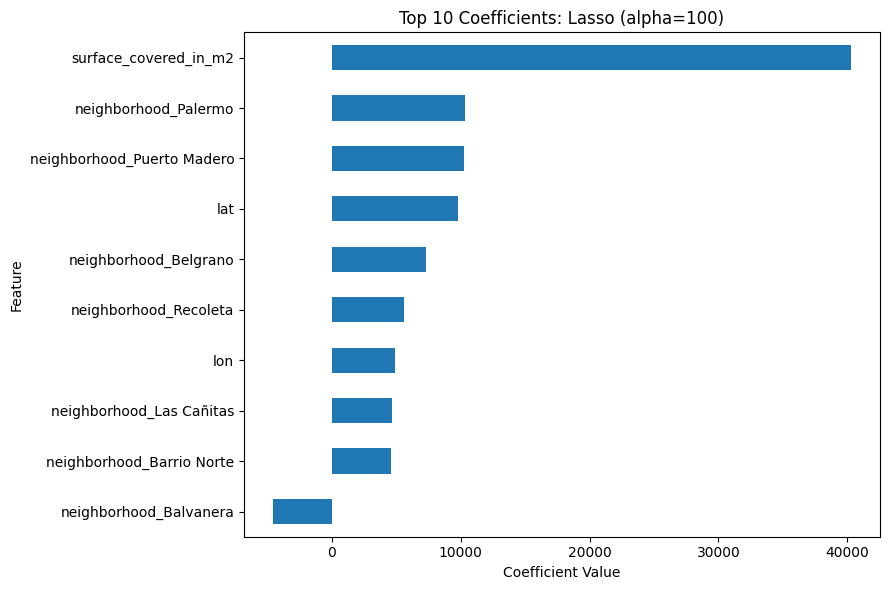

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_3.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax)
ax.set_title("Top 10 Coefficients: Lasso (alpha=100)")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
lasso_zeros_count = (feat_imp_3 == 0).sum()  # <--- (feat_imp_3 == 0).sum()
print(f"Lasso removed {lasso_zeros_count} features out of {len(feat_imp_3)} total features.")
print(f"Percentage removed: {lasso_zeros_count / len(feat_imp_3) * 100:.1f}%")

Lasso removed 3 features out of 59 total features.
Percentage removed: 5.1%


In [19]:
assert 'lasso_zeros_count' in globals(), "❌ 'lasso_zeros_count' is not defined"
assert isinstance(lasso_zeros_count, (int, np.integer)), "❌ Should be an integer count"
assert lasso_zeros_count >= 0, "❌ Zero count should be non-negative"
assert lasso_zeros_count < len(feat_imp_3), "❌ Should not eliminate all features"
assert lasso_zeros_count + (feat_imp_3 != 0).sum() == len(feat_imp_3), "❌ Zero and non-zero counts should sum to total"
print("✓ All assertions passed")

✓ All assertions passed


In [20]:
# Show top 5 positive and negative coefficients
print("=" * 60)
print("TOP 5 POSITIVE FEATURES (Increase Price)")
print("=" * 60)
top_positive = feat_imp_3.nlargest(5)
for feature, coef in top_positive.items():
    print(f"{feature:40} : ${coef:>10,.2f}")

print("\n" + "=" * 60)
print("TOP 5 NEGATIVE FEATURES (Decrease Price)")
print("=" * 60)
top_negative = feat_imp_3.nsmallest(5)
for feature, coef in top_negative.items():
    print(f"{feature:40} : ${coef:>10,.2f}")

print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print("Remember: These coefficients are on STANDARDIZED features.")
print("A feature's importance depends on both its coefficient AND")
print("which other features Lasso eliminated. This is the 'feature selection'")
print("effect of Lasso in action.")

TOP 5 POSITIVE FEATURES (Increase Price)
surface_covered_in_m2                    : $ 40,288.95
neighborhood_Palermo                     : $ 10,307.79
neighborhood_Puerto Madero               : $ 10,259.33
lat                                      : $  9,774.24
neighborhood_Belgrano                    : $  7,279.83

TOP 5 NEGATIVE FEATURES (Decrease Price)
neighborhood_Balvanera                   : $ -4,560.41
neighborhood_Once                        : $ -3,978.74
neighborhood_Boca                        : $ -3,853.26
neighborhood_Congreso                    : $ -2,671.56
neighborhood_Constitución                : $ -2,195.16

INTERPRETATION GUIDE
Remember: These coefficients are on STANDARDIZED features.
A feature's importance depends on both its coefficient AND
which other features Lasso eliminated. This is the 'feature selection'
effect of Lasso in action.


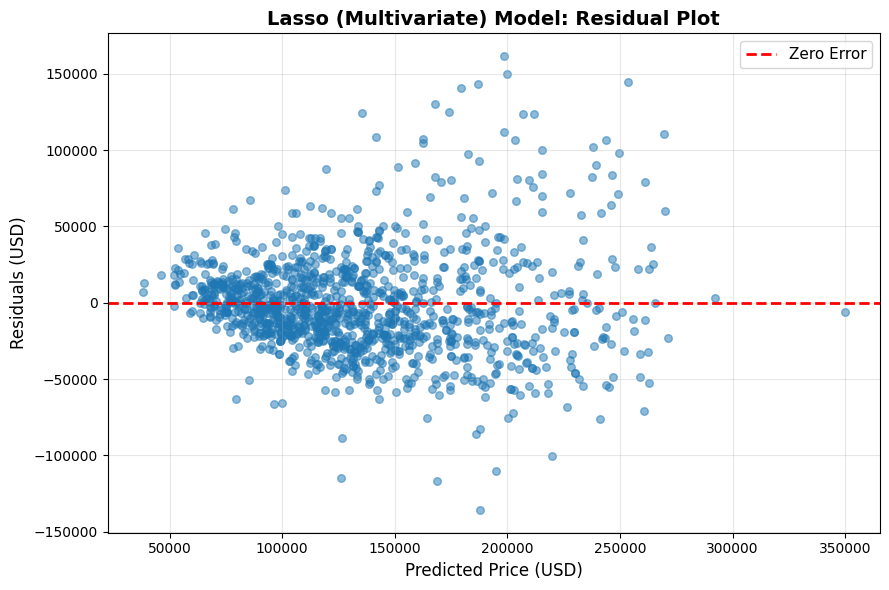

Mean of residuals: $-1,449.38 (should be close to 0)
Std of residuals: $33,034.67
Min residual: $-135,828.79
Max residual: $161,606.27


In [21]:
# Get residuals from Lasso predictions on test set
y_pred_lasso = model_lasso_3.predict(X_test_3)
residuals_lasso = y_test_3 - y_pred_lasso

# Create residual plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_pred_lasso, residuals_lasso, alpha=0.5, s=30)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel("Predicted Price (USD)", fontsize=12)
ax.set_ylabel("Residuals (USD)", fontsize=12)
ax.set_title("Lasso (Multivariate) Model: Residual Plot", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"Mean of residuals: ${residuals_lasso.mean():,.2f} (should be close to 0)")
print(f"Std of residuals: ${residuals_lasso.std():,.2f}")
print(f"Min residual: ${residuals_lasso.min():,.2f}")
print(f"Max residual: ${residuals_lasso.max():,.2f}")

In [22]:
ridge_metrics = {
    "Model": "Ridge (α=1.0)",
    "RMSE_train": rmse_ridge_train,
    "RMSE_test": rmse_ridge_test,
    "Non-zero_features": "All"
}

lasso_metrics = {
    "Model": "Lasso (α=100)",
    "RMSE_train": root_mean_squared_error(y_train_3, model_lasso_3.predict(X_train_3)),
    "RMSE_test": rmse_lasso_test,
    "Non-zero_features": (feat_imp_3 != 0).sum()
}

df_comparison = pd.DataFrame([ridge_metrics, lasso_metrics])
print(df_comparison)

           Model    RMSE_train     RMSE_test Non-zero_features
0  Ridge (α=1.0)  34200.435086  33087.845694               All
1  Lasso (α=100)  34224.825010  33053.242280                56
